# Phase 2 — Modèles Baseline
## Entraînement, évaluation et comparaison

Ce notebook entraîne trois modèles baseline sur les features calculées par `FeatureBuilder` :

| Niveau | Modèle | Rôle |
|--------|--------|------|
| 0 | `DummyClassifier` | Plancher absolu — prédit toujours la classe majoritaire |
| 1 | `LogisticRegression` | Baseline linéaire — nécessite un scaling |
| 2 | `RandomForestClassifier` | Baseline non-linéaire — robuste, souvent difficile à battre |

**Métriques calculées :**
- ML : accuracy, precision, recall, F1-score
- Finance : win rate, profit factor, Sharpe ratio simulé

**Anti-leakage :** validation croisée temporelle (`TimeSeriesSplit`) — jamais de shuffle.

## 1. Imports et configuration

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analytics.db_inspector import DBInspector
from src.ml.feature_engineering.feature_builder import FeatureBuilder
from src.ml.feature_engineering.dataset_builder import DatasetBuilder
from src.ml.models.baseline import BaselineModel
from src.ml.models.evaluator import ModelEvaluator

plt.rcParams["figure.dpi"] = 110
sns.set_style("darkgrid")
pd.set_option("display.float_format", "{:.4f}".format)
print("Imports OK")

2026-03-29 17:26:03,090 - crypto_bot - INFO - ✅ Configuration chargée avec succès


Imports OK


## 2. Chargement des données OHLCV

On charge les données depuis la base SQLite via `DBInspector`.

**Points d'attention :**
- Le `timestamp` arrive en `object` (string) depuis SQLite → conversion explicite en `datetime64` obligatoire.
- On filtre sur `(symbol, timeframe, exchange)` car la table contient plusieurs paires et timeframes mélangés.

In [2]:
# ── Paramètres à modifier selon l'analyse souhaitée ──────────────────────────
SYMBOL    = "BTC/USDT"  # paire présente en base
TIMEFRAME = "1h"        # "1h" | "4h" | "1d"
EXCHANGE  = "binance"   # "binance" | "kraken" | "coinbase"

inspector = DBInspector()

# Chargement brut — contient tous les symboles / timeframes / exchanges
raw_all = inspector.get_ohlcv_data_for_symbol(SYMBOL)

# Filtrage sur la combinaison souhaitée
df_raw = raw_all[
    (raw_all["timeframe"] == TIMEFRAME) &
    (raw_all["exchange"]  == EXCHANGE)
].copy()

# Conversion explicite du timestamp (SQLite retourne des strings, type object)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])

# Tri chronologique strict + reset de l'index (requis par FeatureBuilder)
df_raw = df_raw.sort_values("timestamp").reset_index(drop=True)

print(f"Shape          : {df_raw.shape}")
print(f"Periode        : {df_raw['timestamp'].min()} -> {df_raw['timestamp'].max()}")
print(f"Dtype timestamp: {df_raw['timestamp'].dtype}")
df_raw.tail(3)

2026-03-29 17:26:03,576 - crypto_bot - INFO - Récupération des données OHLCV pour le symbole BTC/USDT...
2026-03-29 17:26:03,686 - crypto_bot - INFO - Données OHLCV récupérées avec succès. Forme: (4200, 16)


Shape          : (1000, 16)
Periode        : 2026-02-05 19:00:00 -> 2026-02-13 20:00:00
Dtype timestamp: datetime64[ns]


,id,timestamp,symbol,timeframe,open,high,low,close,volume,price_range,price_change,price_change_pct,date,exchange,created_at,updated_at
997,fde6f511-f426-47bd-b244-8d0984e8d05c,2026-02-13 19:00:00,BTC/USDT,1h,69129.9900,69236.3300,68918.7900,68938.9100,560.0454,317.5400,-191.0800,-0.2764,2026-02-13,binance,2026-02-13 20:50:27.254942,2026-02-13 20:50:27.256012
998,75a4bf49-c79b-4eb6-ab79-9d4ba62617cf,2026-02-13 20:00:00,BTC/USDT,1h,68938.9100,68973.3500,68718.2000,68850.0100,434.0290,255.1500,-88.9000,-0.1290,2026-02-13,binance,2026-02-13 20:48:26.023335,2026-02-13 20:48:26.024071
999,4f704979-d82c-4752-9c13-a520e41f68b7,2026-02-13 20:00:00,BTC/USDT,1h,68938.9100,68973.3500,68718.2000,68820.7800,450.6593,255.1500,-118.1300,-0.1714,2026-02-13,binance,2026-02-13 20:50:27.254942,2026-02-13 20:50:27.256012


## 3. Construction des features

`FeatureBuilder` calcule ~30 features réparties en 6 groupes :
returns, volatilité, indicateurs techniques, structure des chandeliers, volume, temporel.
Les premières lignes auront des `NaN` (warm-up des indicateurs, ex. SMA50 = 50 NaN).

In [3]:
builder = FeatureBuilder()
df_features = builder.build(df_raw)

META = {"timestamp","open","high","low","close","volume","symbol",
        "timeframe","exchange","id","price_range","price_change",
        "price_change_pct","date","created_at","updated_at"}
feature_cols = [c for c in df_features.columns if c not in META]

print(f"Bougies totales      : {len(df_features)}")
print(f"Features disponibles : {len(feature_cols)}")
print("\nListe des features :")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")

2026-03-29 17:26:03,730 - crypto_bot - INFO - FeatureBuilder.build : 1000 lignes, 45 colonnes totales (+29 features ajoutées).


Bougies totales      : 1000
Features disponibles : 29

Liste des features :
   1. log_return_1
   2. return_4
   3. return_12
   4. return_24
   5. volatility_5
   6. volatility_10
   7. volatility_20
   8. rsi_14
   9. macd
  10. macd_signal
  11. macd_hist
  12. bb_position
  13. bb_width
  14. sma_7_ratio
  15. sma_20_ratio
  16. sma_50_ratio
  17. ema_9_ratio
  18. ema_21_ratio
  19. hl_spread
  20. body_ratio
  21. upper_wick_ratio
  22. lower_wick_ratio
  23. volume_ma_ratio
  24. volume_change
  25. hour
  26. day_of_week
  27. day_of_month
  28. month
  29. is_weekend


## 4. Création du dataset supervisé

`DatasetBuilder` construit la cible sans data leakage :

```
target(t) = 1  si close(t + horizon) > close(t)   [hausse]
           = 0  sinon                               [baisse ou neutre]
```

Les `horizon` dernières lignes sont supprimées car on ne connait pas encore
le prix futur. Les premières lignes NaN (warm-up indicateurs) sont aussi retirées.

2026-03-29 17:26:03,738 - crypto_bot - INFO - DatasetBuilder.build : 49 lignes supprimées (NaN / horizon). Dataset : 951 lignes × 29 features. Horizon=1, mode='direction'.


X : (951, 29)  |  y : (951,)

Distribution de la target :
  Baisse (0) :   868  (91.3 %)
  Hausse (1) :    83  (8.7 %)


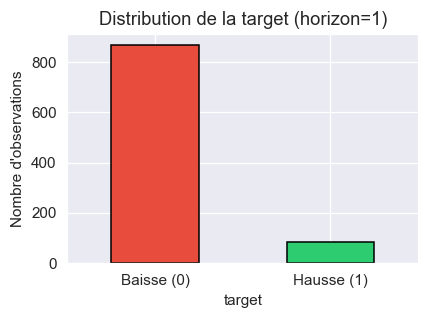

In [4]:
HORIZON = 1   # prédire la direction de la prochaine bougie

dataset_builder = DatasetBuilder(horizon=HORIZON, mode="direction")
X, y = dataset_builder.build(df_features)

print(f"X : {X.shape}  |  y : {y.shape}")
print("\nDistribution de la target :")
vc = y.value_counts()
for label, name in [(0, "Baisse"), (1, "Hausse")]:
    n = vc.get(label, 0)
    print(f"  {name} ({label}) : {n:5d}  ({n/len(y)*100:.1f} %)")

fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().sort_index().plot(kind="bar", ax=ax,
    color=["#e74c3c", "#2ecc71"], edgecolor="black")
ax.set_xticklabels(["Baisse (0)", "Hausse (1)"], rotation=0)
ax.set_title(f"Distribution de la target (horizon={HORIZON})")
ax.set_ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

## 5. Split train / test temporel

On réserve les **20 % les plus récents** comme jeu de test final.
L'entraînement et la sélection de modèle se font uniquement sur le train.

> Important : on ne shuffle jamais — les données sont temporelles.

2026-03-29 17:26:03,822 - crypto_bot - INFO - DatasetBuilder.train_test_split_temporal : train=760, test=191 (ratio=0.2).


Train :   760 observations  (80 %)
Test  :   191 observations  (20 %)


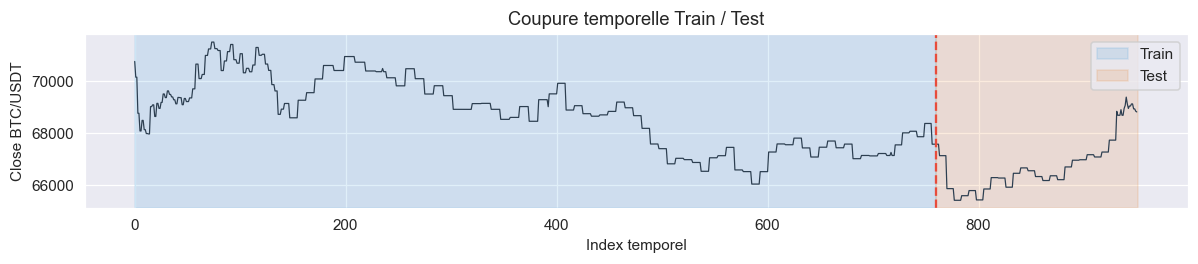

In [5]:
X_train, X_test, y_train, y_test = dataset_builder.train_test_split_temporal(
    X, y, test_ratio=0.2
)

print(f"Train : {len(X_train):5d} observations  ({len(X_train)/len(X)*100:.0f} %)")
print(f"Test  : {len(X_test):5d} observations  ({len(X_test)/len(X)*100:.0f} %)")

# Visualisation de la coupure temporelle sur le cours du BTC
n_valid = len(X)
close_vals = df_features["close"].dropna().iloc[-n_valid:].values
split_idx = len(X_train)

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axvspan(0, split_idx, alpha=0.15, color="#3498db", label="Train")
ax.axvspan(split_idx, n_valid, alpha=0.15, color="#e67e22", label="Test")
ax.plot(close_vals, linewidth=0.8, color="#2c3e50")
ax.axvline(split_idx, color="#e74c3c", linestyle="--", linewidth=1.5)
ax.set_title("Coupure temporelle Train / Test")
ax.legend()
ax.set_xlabel("Index temporel")
ax.set_ylabel("Close BTC/USDT")
plt.tight_layout()
plt.show()

## 6. Validation croisée temporelle (5 folds)

On évalue les trois modèles avec `TimeSeriesSplit(n_splits=5)` sur le **train set**.
Chaque fold garantit que la validation est strictement postérieure à l'entraînement :

```
Fold 1 : [■■] [□]
Fold 2 : [■■■] [□]
Fold 3 : [■■■■] [□]
...
```

In [6]:
N_SPLITS = 5
evaluator = ModelEvaluator()
all_results = {}

for model_type in ("dummy", "logistic_regression", "random_forest"):
    print(f"\n{'─' * 55}")
    print(f" Modele : {model_type}")
    model = BaselineModel(model_type=model_type)
    fold_results = model.cross_validate(X_train, y_train, n_splits=N_SPLITS)
    all_results[model_type] = fold_results
    summary = evaluator.evaluate_folds(fold_results)
    evaluator.print_summary(summary, model_name=model_type)

print("\nValidation croisee terminee.")

2026-03-29 17:26:03,887 - crypto_bot - INFO -   Fold 1/5 | train=130 val=126 | accuracy=0.9365
2026-03-29 17:26:03,890 - crypto_bot - INFO -   Fold 2/5 | train=256 val=126 | accuracy=0.9524
2026-03-29 17:26:03,893 - crypto_bot - INFO -   Fold 3/5 | train=382 val=126 | accuracy=0.9444
2026-03-29 17:26:03,896 - crypto_bot - INFO -   Fold 4/5 | train=508 val=126 | accuracy=0.9365



───────────────────────────────────────────────────────
 Modele : dummy


2026-03-29 17:26:03,899 - crypto_bot - INFO -   Fold 5/5 | train=634 val=126 | accuracy=0.9206
2026-03-29 17:26:03,899 - crypto_bot - INFO - BaselineModel(dummy).cross_validate : accuracy moyenne = 0.9381
2026-03-29 17:26:03,903 - crypto_bot - INFO -   Fold 1 | acc=0.9365 f1=0.0000 sharpe=167.544
2026-03-29 17:26:03,906 - crypto_bot - INFO -   Fold 2 | acc=0.9524 f1=0.0000 sharpe=198.820
2026-03-29 17:26:03,910 - crypto_bot - INFO -   Fold 3 | acc=0.9444 f1=0.0000 sharpe=181.601
2026-03-29 17:26:03,913 - crypto_bot - INFO -   Fold 4 | acc=0.9365 f1=0.0000 sharpe=167.544
2026-03-29 17:26:03,916 - crypto_bot - INFO -   Fold 5 | acc=0.9206 f1=0.0000 sharpe=145.646
2026-03-29 17:26:03,916 - crypto_bot - INFO - ModelEvaluator.evaluate_folds : accuracy=0.9381±0.0105 | f1=0.0000±0.0000 | sharpe=172.231


=== dummy ===
  Accuracy       : 0.9381 ± 0.0105
  Precision      : 0.0000 ± 0.0000
  Recall         : 0.0000 ± 0.0000
  F1-score       : 0.0000 ± 0.0000
  Win rate       : 0.9381 ± 0.0105
  Profit factor  : 15.6200 ± 2.7843
  Sharpe simulé  : 172.2310 ± 17.5811

───────────────────────────────────────────────────────
 Modele : logistic_regression


2026-03-29 17:26:03,955 - crypto_bot - INFO -   Fold 1/5 | train=130 val=126 | accuracy=0.6905
2026-03-29 17:26:03,960 - crypto_bot - INFO -   Fold 2/5 | train=256 val=126 | accuracy=0.7937
2026-03-29 17:26:03,965 - crypto_bot - INFO -   Fold 3/5 | train=382 val=126 | accuracy=0.8571
2026-03-29 17:26:03,970 - crypto_bot - INFO -   Fold 4/5 | train=508 val=126 | accuracy=0.8730
2026-03-29 17:26:03,974 - crypto_bot - INFO -   Fold 5/5 | train=634 val=126 | accuracy=0.9206
2026-03-29 17:26:03,975 - crypto_bot - INFO - BaselineModel(logistic_regression).cross_validate : accuracy moyenne = 0.8270
2026-03-29 17:26:03,979 - crypto_bot - INFO -   Fold 1 | acc=0.6905 f1=0.2041 sharpe=38.563
2026-03-29 17:26:03,982 - crypto_bot - INFO -   Fold 2 | acc=0.7937 f1=0.1333 sharpe=67.915
2026-03-29 17:26:03,985 - crypto_bot - INFO -   Fold 3 | acc=0.8571 f1=0.1818 sharpe=95.525
2026-03-29 17:26:03,989 - crypto_bot - INFO -   Fold 4 | acc=0.8730 f1=0.2727 sharpe=104.856
2026-03-29 17:26:03,993 - crypto

=== logistic_regression ===
  Accuracy       : 0.8270 ± 0.0794
  Precision      : 0.1106 ± 0.0698
  Recall         : 0.3238 ± 0.1999
  F1-score       : 0.1584 ± 0.0910
  Win rate       : 0.8270 ± 0.0794
  Profit factor  : 6.1104 ± 3.1910
  Sharpe simulé  : 90.5011 ± 35.9999

───────────────────────────────────────────────────────
 Modele : random_forest


2026-03-29 17:26:04,156 - crypto_bot - INFO -   Fold 1/5 | train=130 val=126 | accuracy=0.6587
2026-03-29 17:26:04,314 - crypto_bot - INFO -   Fold 2/5 | train=256 val=126 | accuracy=0.9444
2026-03-29 17:26:04,491 - crypto_bot - INFO -   Fold 3/5 | train=382 val=126 | accuracy=0.9444
2026-03-29 17:26:04,679 - crypto_bot - INFO -   Fold 4/5 | train=508 val=126 | accuracy=0.9206
2026-03-29 17:26:04,850 - crypto_bot - INFO -   Fold 5/5 | train=634 val=126 | accuracy=0.9206
2026-03-29 17:26:04,851 - crypto_bot - INFO - BaselineModel(random_forest).cross_validate : accuracy moyenne = 0.8778
2026-03-29 17:26:04,855 - crypto_bot - INFO -   Fold 1 | acc=0.6587 f1=0.1569 sharpe=31.333
2026-03-29 17:26:04,858 - crypto_bot - INFO -   Fold 2 | acc=0.9444 f1=0.0000 sharpe=181.601
2026-03-29 17:26:04,862 - crypto_bot - INFO -   Fold 3 | acc=0.9444 f1=0.0000 sharpe=181.601
2026-03-29 17:26:04,866 - crypto_bot - INFO -   Fold 4 | acc=0.9206 f1=0.0000 sharpe=145.646
2026-03-29 17:26:04,869 - crypto_bot

=== random_forest ===
  Accuracy       : 0.8778 ± 0.1100
  Precision      : 0.1186 ± 0.1941
  Recall         : 0.1400 ± 0.1960
  F1-score       : 0.0885 ± 0.1158
  Win rate       : 0.8778 ± 0.1100
  Profit factor  : 11.8260 ± 5.5058
  Sharpe simulé  : 137.1654 ± 55.3050

Validation croisee terminee.


## 7. Comparaison des modèles

`ModelEvaluator.compare_models()` agrège les métriques moyennes de chaque modèle
en un seul DataFrame pour faciliter la comparaison visuelle et le choix du meilleur modèle.

In [7]:
comparison = evaluator.compare_models(all_results)
cols_to_show = ["accuracy", "precision", "recall", "f1", "win_rate", "profit_factor", "sharpe"]
display(comparison[cols_to_show])

2026-03-29 17:26:04,879 - crypto_bot - INFO -   Fold 1 | acc=0.9365 f1=0.0000 sharpe=167.544
2026-03-29 17:26:04,883 - crypto_bot - INFO -   Fold 2 | acc=0.9524 f1=0.0000 sharpe=198.820
2026-03-29 17:26:04,886 - crypto_bot - INFO -   Fold 3 | acc=0.9444 f1=0.0000 sharpe=181.601
2026-03-29 17:26:04,890 - crypto_bot - INFO -   Fold 4 | acc=0.9365 f1=0.0000 sharpe=167.544
2026-03-29 17:26:04,893 - crypto_bot - INFO -   Fold 5 | acc=0.9206 f1=0.0000 sharpe=145.646
2026-03-29 17:26:04,894 - crypto_bot - INFO - ModelEvaluator.evaluate_folds : accuracy=0.9381±0.0105 | f1=0.0000±0.0000 | sharpe=172.231
2026-03-29 17:26:04,906 - crypto_bot - INFO -   Fold 1 | acc=0.6905 f1=0.2041 sharpe=38.563
2026-03-29 17:26:04,937 - crypto_bot - INFO -   Fold 2 | acc=0.7937 f1=0.1333 sharpe=67.915
2026-03-29 17:26:04,944 - crypto_bot - INFO -   Fold 3 | acc=0.8571 f1=0.1818 sharpe=95.525
2026-03-29 17:26:04,953 - crypto_bot - INFO -   Fold 4 | acc=0.8730 f1=0.2727 sharpe=104.856
2026-03-29 17:26:04,957 - cry

,accuracy,precision,recall,f1,win_rate,profit_factor,sharpe
model,,,,,,,
dummy,0.9381,0.0000,0.0000,0.0000,0.9381,15.6200,172.2310
logistic_regression,0.8270,0.1106,0.3238,0.1584,0.8270,6.1104,90.5011
random_forest,0.8778,0.1186,0.1400,0.0885,0.8778,11.8260,137.1654


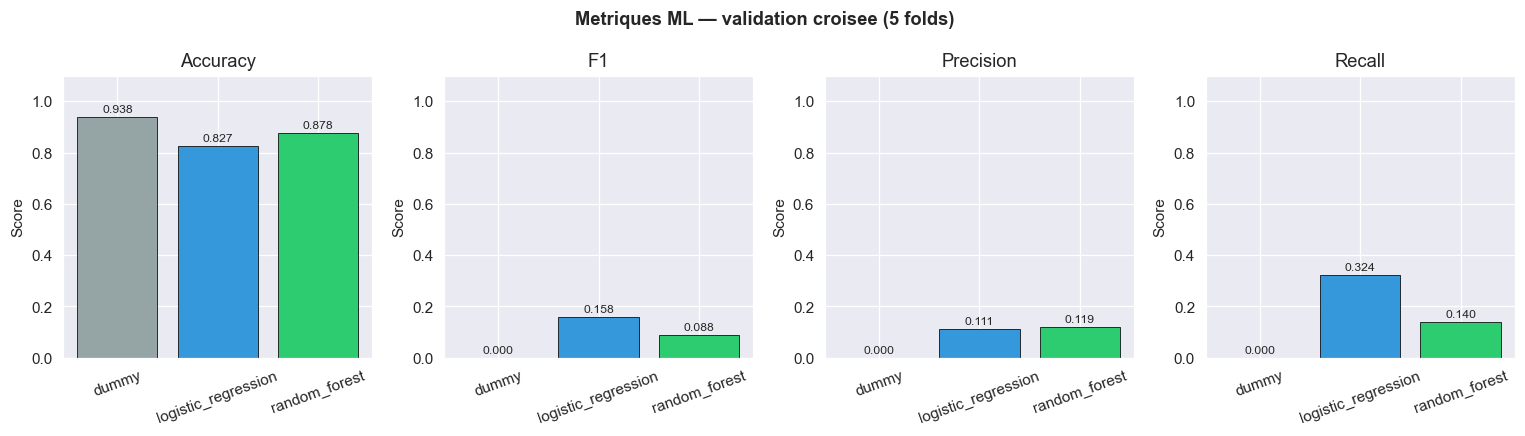

In [8]:
# ── Graphique 1 : métriques ML ──
colors = {"dummy": "#95a5a6", "logistic_regression": "#3498db", "random_forest": "#2ecc71"}
metrics_ml = ["accuracy", "f1", "precision", "recall"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
for ax, metric in zip(axes, metrics_ml):
    vals = comparison[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[colors[m] for m in vals.index],
                  edgecolor="black", linewidth=0.5)
    ax.set_title(metric.capitalize())
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=20)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Metriques ML — validation croisee (5 folds)", fontweight="bold")
plt.tight_layout()
plt.show()

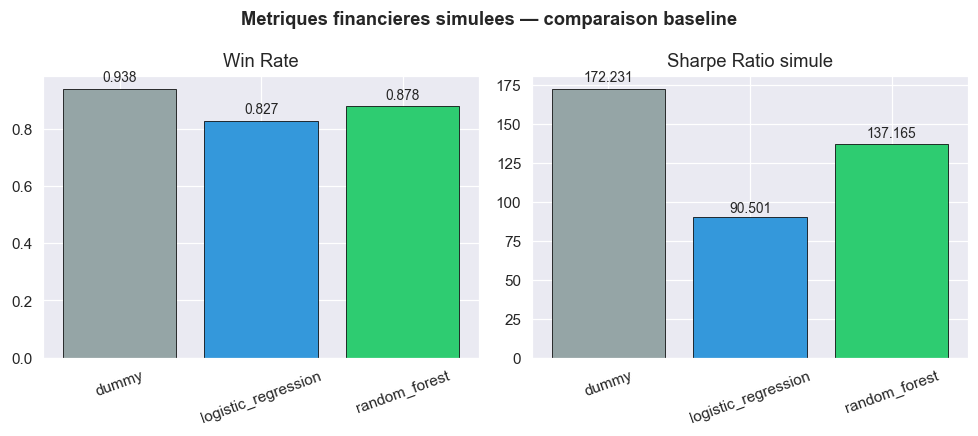

In [9]:
# ── Graphique 2 : métriques financières ──
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, metric, label in zip(axes,
                               ["win_rate", "sharpe"],
                               ["Win Rate", "Sharpe Ratio simule"]):
    vals = comparison[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[colors[m] for m in vals.index],
                  edgecolor="black", linewidth=0.5)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=20)
    for bar, v in zip(bars, vals.values):
        offset = max(abs(v) * 0.03, 0.01)
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset if v >= 0 else bar.get_height() - offset * 3,
                f"{v:.3f}", ha="center", fontsize=9)

fig.suptitle("Metriques financieres simulees — comparaison baseline", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Évaluation finale sur le Test Set

On ré-entraîne chaque modèle sur l'intégralité du **train set** et on évalue
**une seule fois** sur le **test set** (données les plus récentes).

> Cette étape est définitive — on ne retouche pas aux hyperparamètres après.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

test_results = {}

for model_type in ("dummy", "logistic_regression", "random_forest"):
    model = BaselineModel(model_type=model_type)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_results[model_type] = {"model": model, "y_pred": y_pred}

    print(f"\n── {model_type} ──")
    print(classification_report(y_test, y_pred, target_names=["Baisse", "Hausse"]))

2026-03-29 17:26:05,260 - crypto_bot - INFO - BaselineModel(dummy).fit : 760 lignes, 29 features.
2026-03-29 17:26:05,269 - crypto_bot - INFO - BaselineModel(logistic_regression).fit : 760 lignes, 29 features.
2026-03-29 17:26:05,415 - crypto_bot - INFO - BaselineModel(random_forest).fit : 760 lignes, 29 features.



── dummy ──
              precision    recall  f1-score   support

      Baisse       0.90      1.00      0.94       171
      Hausse       0.00      0.00      0.00        20

    accuracy                           0.90       191
   macro avg       0.45      0.50      0.47       191
weighted avg       0.80      0.90      0.85       191


── logistic_regression ──
              precision    recall  f1-score   support

      Baisse       0.94      0.85      0.89       171
      Hausse       0.30      0.55      0.39        20

    accuracy                           0.82       191
   macro avg       0.62      0.70      0.64       191
weighted avg       0.87      0.82      0.84       191


── random_forest ──
              precision    recall  f1-score   support

      Baisse       0.93      0.95      0.94       171
      Hausse       0.47      0.35      0.40        20

    accuracy                           0.89       191
   macro avg       0.70      0.65      0.67       191
weighted avg 

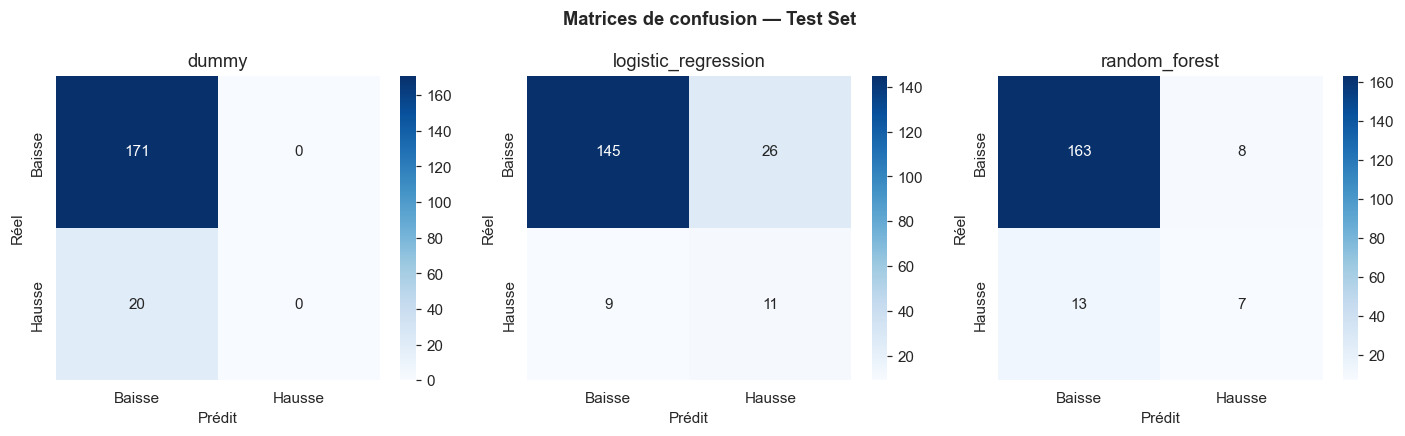

In [11]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (model_type, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["Baisse", "Hausse"],
                yticklabels=["Baisse", "Hausse"])
    ax.set_title(model_type)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

fig.suptitle("Matrices de confusion — Test Set", fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Importance des features

- **Random Forest** : `feature_importances_` (gain moyen d'impureté Gini)
- **Logistic Regression** : `|coef_|` (valeur absolue des coefficients)

Ces importances indiquent quelles features sont les plus discriminantes
pour distinguer hausse/baisse sur BTC/USDT 1h.

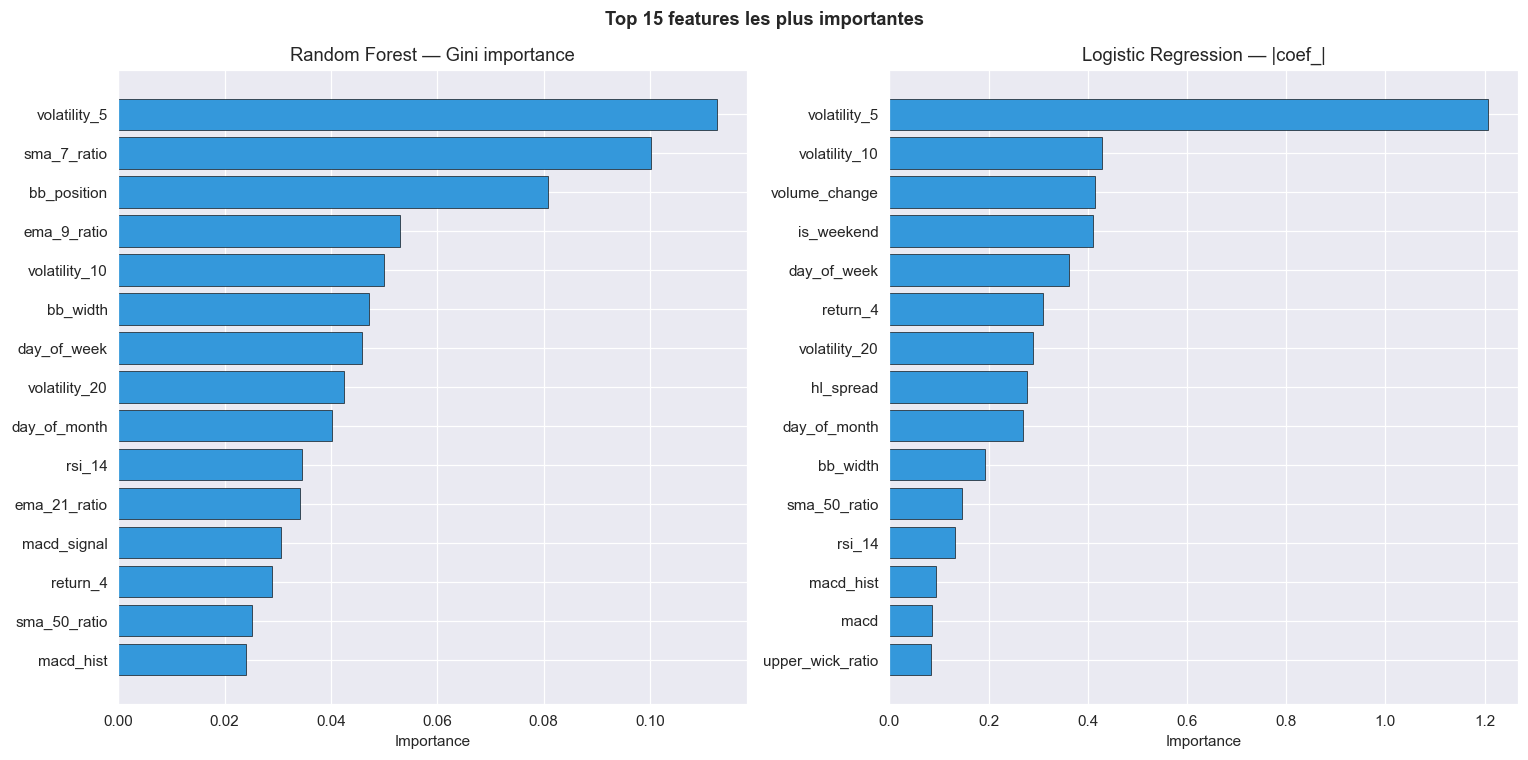

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, model_type, title in zip(
    axes,
    ("random_forest", "logistic_regression"),
    ("Random Forest — Gini importance", "Logistic Regression — |coef_|")
):
    model = test_results[model_type]["model"]
    imp = model.feature_importances()
    top15 = imp.head(15)

    ax.barh(top15.index[::-1], top15.values[::-1],
            color="#3498db", edgecolor="black", linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel("Importance")

plt.suptitle("Top 15 features les plus importantes", fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Récapitulatif

### Ce qu'on a fait dans ce notebook
1. Chargé les données OHLCV et calculé les ~30 features avec `FeatureBuilder`
2. Construit le dataset supervisé (target = direction à horizon=1) avec `DatasetBuilder`
3. Entraîné 3 niveaux de baseline via `BaselineModel` + validation croisée temporelle
4. Comparé les modèles via `ModelEvaluator` (métriques ML + métriques financières)
5. Évaluation finale sur le test set (données les plus récentes)
6. Visualisé les importances de features

### Seuil à dépasser

| Métrique | Dummy | Objectif Phase 3 |
|----------|-------|-----------------|
| Accuracy | ~0.50 | > 0.55 |
| F1 | ~0.33-0.50 | > F1 du meilleur baseline |
| Sharpe simulé | ~0 | > 0.5 |
| Win rate | ~0.50 | > 0.55 |

### Phase suivante — Phase 3
- Tuner un modèle plus puissant (XGBoost, LightGBM) en partant des features importantes
- Optimisation des hyperparamètres avec Optuna ou GridSearchCV
- Backtesting plus réaliste (frais, slippage)